In [27]:
#Step 1 — Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

%matplotlib inline

In [28]:
#Step 2 — Load Dataset
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
#Display first 5 rows
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [29]:
#Step 3 — Data Understanding
#Shape
df.shape
#Columns
df.columns
#Dataset Information
df.info()
#Statistical Summary
df.describe(include="all")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,7043,7043,7043.000000,7043,7043,7043.000000,7043,7043,7043,7043,...,7043,7043,7043,7043,7043,7043,7043,7043.000000,7043,7043
unique,7043,2,NaN,2,2,NaN,2,3,3,3,...,3,3,3,3,3,2,4,NaN,6531,2
top,3186-AJIEK,Male,NaN,No,No,NaN,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,NaN,,No
freq,1,3555,NaN,3641,4933,NaN,6361,3390,3096,3498,...,3095,3473,2810,2785,3875,4171,2365,NaN,11,5174
mean,NaN,NaN,0.162147,NaN,NaN,32.371149,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,64.761692,NaN,NaN
std,NaN,NaN,0.368612,NaN,NaN,24.559481,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,30.090047,NaN,NaN
min,NaN,NaN,0.000000,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.250000,NaN,NaN
25%,NaN,NaN,0.000000,NaN,NaN,9.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35.500000,NaN,NaN
50%,NaN,NaN,0.000000,NaN,NaN,29.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,70.350000,NaN,NaN
75%,NaN,NaN,0.000000,NaN,NaN,55.000000,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,89.850000,NaN,NaN


In [30]:
#Step 4 — Data Cleaning
#Check Missing Values
df.isnull().sum()
#Check Duplicate Rows
df.duplicated().sum()
df = df.drop_duplicates()
#Convert TotalCharges into Numeric
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
#Check Missing Values Again
df.isnull().sum()
#Fill Missing Values
df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)
#Remove Customer ID
df.drop("customerID", axis=1, inplace=True)


/tmp/ipykernel_589/3748213007.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["TotalCharges"].fillna(df["TotalCharges"].median(), inplace=True)


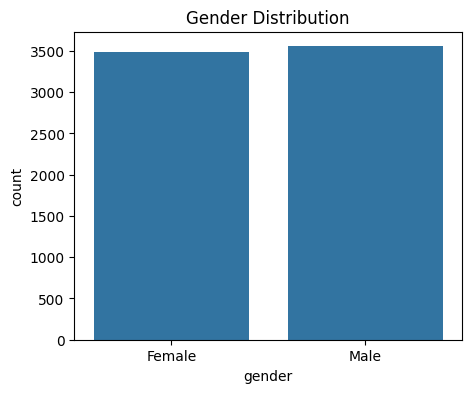

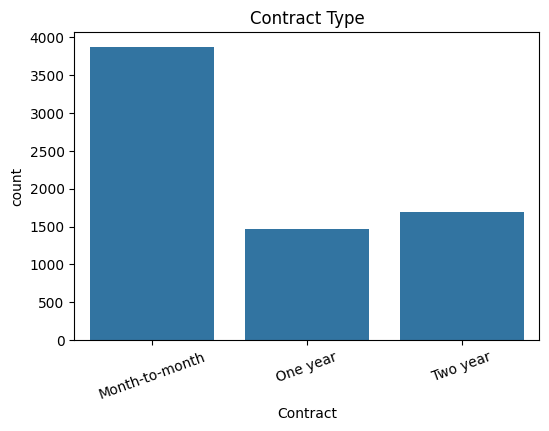

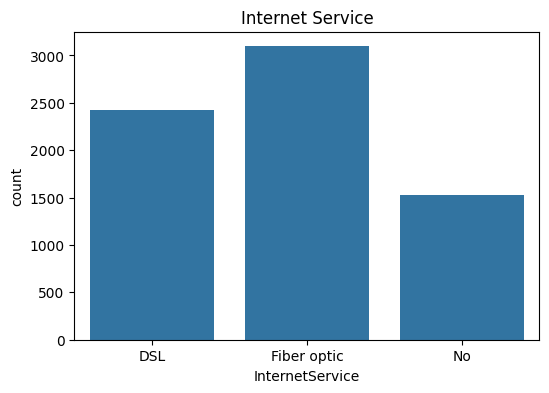

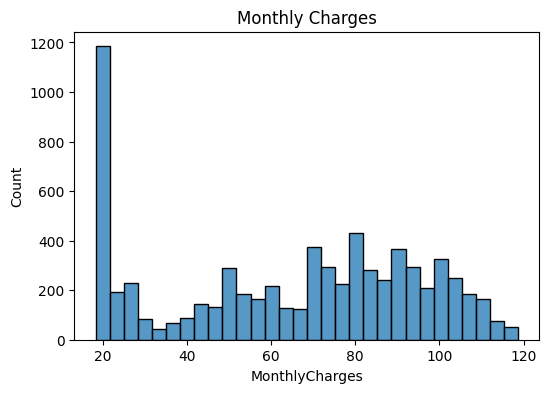

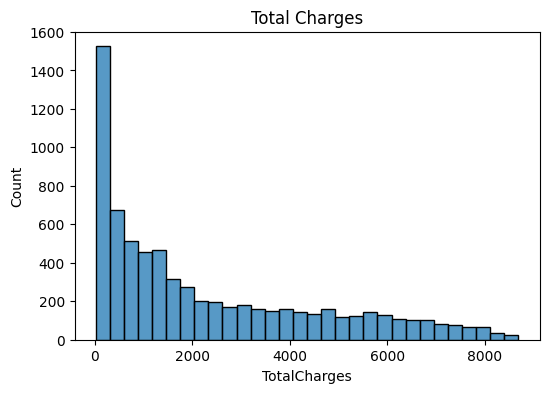

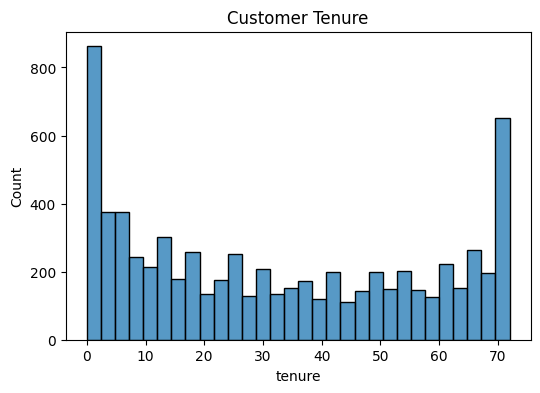

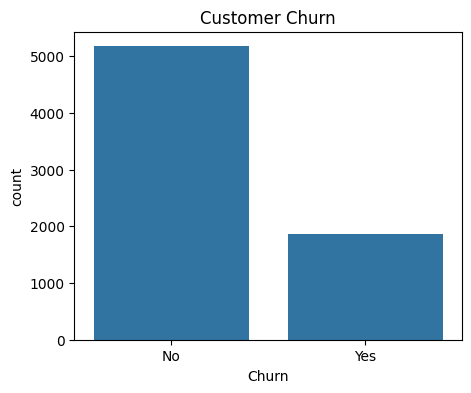

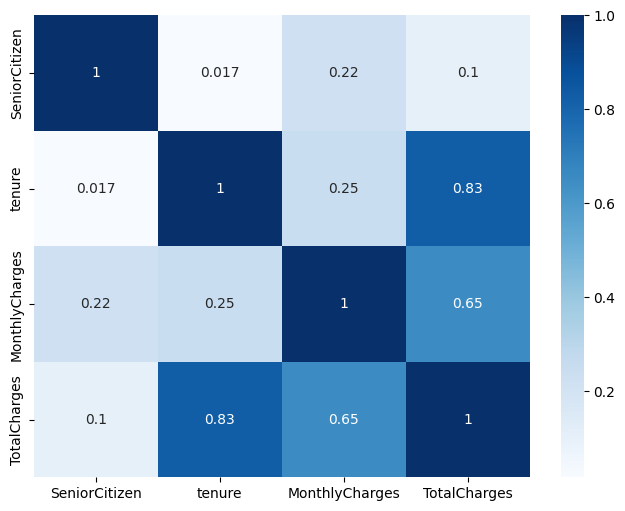

In [31]:
#Step 5 — Exploratory Data Analysis (EDA)
#general Distribution
plt.figure(figsize=(5,4))
sns.countplot(x="gender", data=df)
plt.title("Gender Distribution")
plt.show()
#Contract Distribution
plt.figure(figsize=(6,4))
sns.countplot(x="Contract", data=df)
plt.title("Contract Type")
plt.xticks(rotation=20)
plt.show()
#Internet Service
plt.figure(figsize=(6,4))
sns.countplot(x="InternetService", data=df)
plt.title("Internet Service")
plt.show()
#Monthly Charges
plt.figure(figsize=(6,4))
sns.histplot(df["MonthlyCharges"], bins=30)
plt.title("Monthly Charges")
plt.show()
#Total Charges
plt.figure(figsize=(6,4))
sns.histplot(df["TotalCharges"], bins=30)
plt.title("Total Charges")
plt.show()
#Tenure
plt.figure(figsize=(6,4))
sns.histplot(df["tenure"], bins=30)
plt.title("Customer Tenure")
plt.show()
#Churn Distribution
plt.figure(figsize=(5,4))
sns.countplot(x="Churn", data=df)
plt.title("Customer Churn")
plt.show()
#Correlation Heatmap
numeric_df = df.select_dtypes(include=["number"])

plt.figure(figsize=(8,6))
sns.heatmap(numeric_df.corr(), annot=True, cmap="Blues")
plt.show()

In [32]:
#Step 6 — Feature Engineering
features = [
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]

In [33]:
#Step 7 - Feature Selection
X = df[features]
#Display
X.head()

,tenure,MonthlyCharges,TotalCharges
0,1,29.85,29.85
1,34,56.95,1889.50
2,2,53.85,108.15
3,45,42.30,1840.75
4,2,70.70,151.65


In [34]:
#Step 8 — Feature Scaling
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

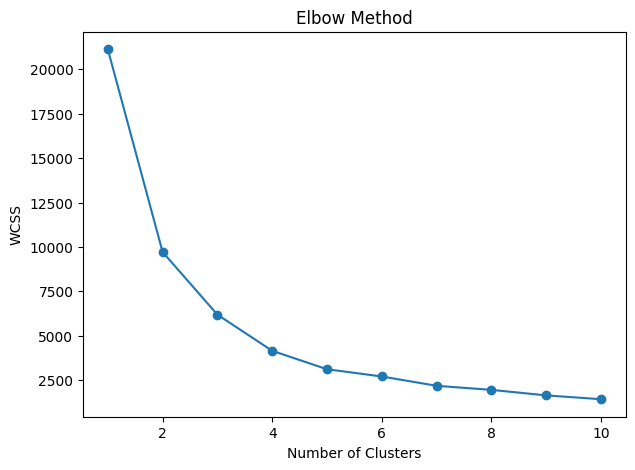

In [35]:
#Step 9 — Elbow Method
wcss = []

for i in range(1,11):

    model = KMeans(
        n_clusters=i,
        random_state=42
    )

    model.fit(X_scaled)

    wcss.append(model.inertia_)
#Plot
plt.figure(figsize=(7,5))

plt.plot(range(1,11), wcss, marker="o")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.title("Elbow Method")

plt.show()

In [36]:
#Step 10 — Build K-Means Model
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

df["Cluster"] = kmeans.fit_predict(X_scaled)

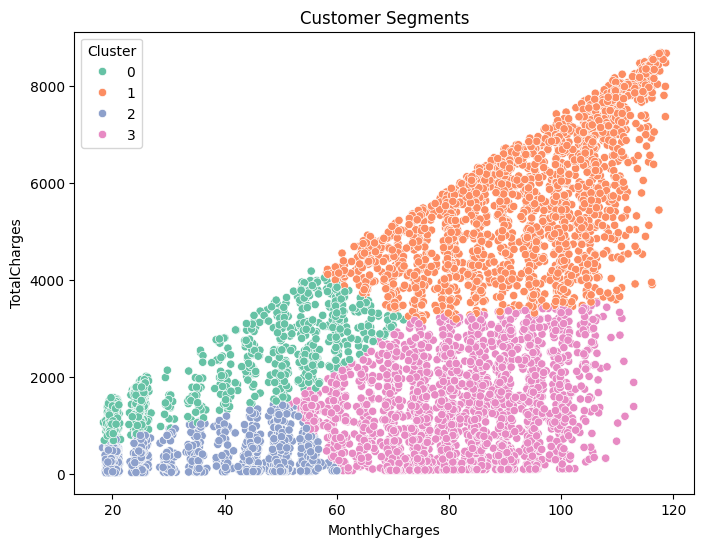

In [37]:
#Step 11 — Cluster Visualization
plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df,
    x="MonthlyCharges",
    y="TotalCharges",
    hue="Cluster",
    palette="Set2"
)

plt.title("Customer Segments")

plt.show()

In [38]:
#Step 12 — Customer Segment Analysis
#Average Values
df.groupby("Cluster")[[
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]].mean()
#Customer count
df["Cluster"].value_counts()

,count
Cluster,
3,2276
1,1904
2,1704
0,1159


In [39]:
#Step 13 — Business Insights
#Example interpretations:

#Cluster 0

#New customers
#Low tenure
#Low spending

#Cluster 1

#Loyal customers
#High tenure
#High lifetime value

#Cluster 2

#High monthly charges
#Medium tenure
#Premium plans

#Cluster 3

#Low monthly charges
#Stable customers
#Budget plans

#(The actual descriptions will depend on your clustering results.)

In [40]:
#Step 14 — Save Final Dataset
df.to_csv("Customer_Segmentation_Result.csv", index=False)
#To Download:
from google.colab import files

files.download("Customer_Segmentation_Result.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Customer Profile

In [45]:
#Average Customer Behavior
#Step 1 — Average values of each cluster

cluster_summary = df.groupby("Cluster")[[
    "tenure",
    "MonthlyCharges",
    "TotalCharges"
]].mean().round(2)

cluster_summary

,tenure,MonthlyCharges,TotalCharges
Cluster,,,
0,53.59,34.92,1836.58
1,59.53,93.31,5548.65
2,10.23,31.77,308.96
3,15.42,80.78,1253.01


In [47]:
#Customer Count
#Step 2: Number of customers in each cluster

cluster_count = df["Cluster"].value_counts().sort_index()
cluster_count

,count
Cluster,
0,1159
1,1904
2,1704
3,2276


In [48]:
#Contract Type
#Step 3: Contract Type Analysis

contract_analysis = pd.crosstab(
    df["Cluster"],
    df["Contract"]
)

contract_analysis

Contract,Month-to-month,One year,Two year
Cluster,,,
0,189,336,634
1,494,580,830
2,1235,289,180
3,1957,268,51


In [49]:
#Internet Service
#Step 4: Internet Service Analysis

internet_analysis = pd.crosstab(
    df["Cluster"],
    df["InternetService"]
)

internet_analysis

InternetService,DSL,Fiber optic,No
Cluster,,,
0,515,1,643
1,558,1346,0
2,821,0,883
3,527,1749,0


In [50]:
#Payment Method
#Step 5: Payment Method Analysis

payment_analysis = pd.crosstab(
    df["Cluster"],
    df["PaymentMethod"]
)

payment_analysis

PaymentMethod,Bank transfer (automatic),Credit card (automatic),Electronic check,Mailed check
Cluster,,,,
0,365,345,169,280
1,613,586,572,133
2,204,254,390,856
3,362,337,1234,343


In [53]:
#Churn Analysis
#Step 6: Churn Analysis (%)

churn_analysis = (
    pd.crosstab(
        df["Cluster"],
        df["Churn"],
        normalize="index"
    ) * 100
).round(2)

churn_analysis

Churn,No,Yes
Cluster,,
0,95.00,5.00
1,84.61,15.39
2,75.35,24.65
3,51.76,48.24


In [54]:
#Customer Profile
#Step 7: Final Customer Profile

customer_profile = df.groupby("Cluster").agg({
    "tenure": "mean",
    "MonthlyCharges": "mean",
    "TotalCharges": "mean"
}).round(2)

customer_profile

,tenure,MonthlyCharges,TotalCharges
Cluster,,,
0,53.59,34.92,1836.58
1,59.53,93.31,5548.65
2,10.23,31.77,308.96
3,15.42,80.78,1253.01


# Cluster Analysis

## Cluster 0 – Loyal Basic Customers

- Long average tenure (53.59 months)
- Low monthly charges (34.92)
- Mostly Two-year contracts
- Very low churn (5%)

**Interpretation:**
Customers in this cluster are loyal and prefer affordable long-term plans.

## Cluster 1 – Premium Loyal Customers

- Highest tenure (59.53 months)
- Highest monthly charges (93.31)
- Highest total spending (5548.65)
- Mostly Fiber Optic users
- Low churn (15.39%)

**Interpretation:**
These are premium customers who generate the highest revenue.

## Cluster 2 – New Budget Customers

- Low tenure (10.23 months)
- Lowest monthly charges (31.77)
- Mostly Month-to-month contracts
- Moderate churn (24.65%)

**Interpretation:**
These customers are new and spend less. They may need promotional offers to improve retention.

## Cluster 3 – High-Risk Customers

- Moderate monthly charges (80.78)
- Mostly Fiber Optic users
- Mostly Month-to-month contracts
- Highest churn (48.24%)

**Interpretation:**
This cluster has the highest risk of leaving the company and should be targeted with retention strategies.

# Business Insights

1. Cluster 1 contains the company's most valuable customers because they have the highest spending and longest tenure.

2. Cluster 0 consists of loyal customers with affordable plans and the lowest churn rate.

3. Cluster 2 represents new customers with lower spending who may benefit from promotional offers.

4. Cluster 3 has the highest churn rate, making it the primary target for customer retention strategies.

5. Long-term contracts are associated with better customer retention, while month-to-month contracts are more common among customers with higher churn.


# Conclusion

This project successfully segmented telecom customers into four distinct groups using the K-Means clustering algorithm. The analysis identified customer behavior patterns based on tenure, monthly charges, total charges, contract type, internet service, payment method, and churn rate. These insights can help businesses improve customer retention, design targeted marketing campaigns, and increase customer lifetime value.
